In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
df_index=pd.read_csv("economic_index.csv")

In [6]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [7]:
#drop unnecessary column
df_index.drop(columns=['Unnamed: 0','year','month'],axis=1,inplace=True)

In [8]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [9]:
#check whether null values
df_index.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


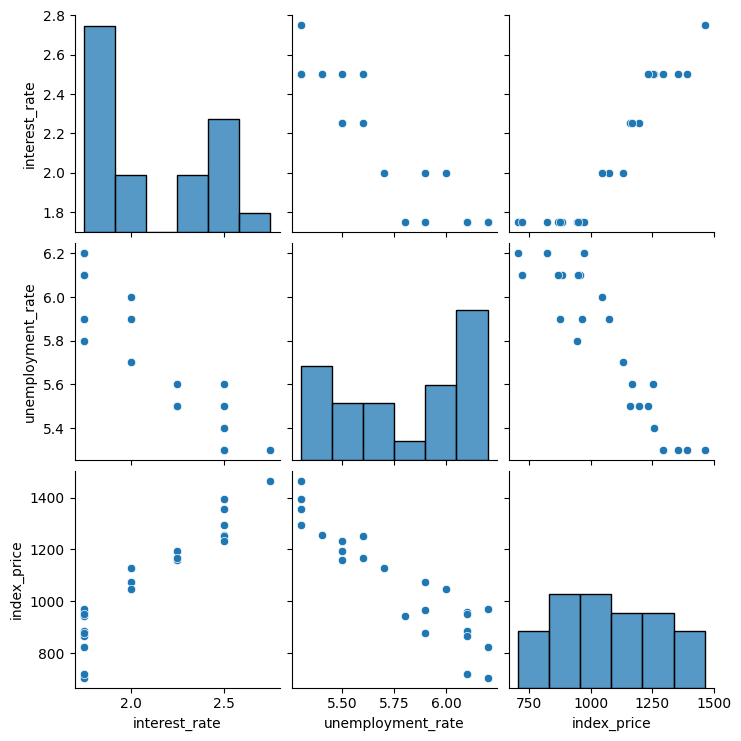

In [10]:
#visualization
import seaborn as sns
sns.pairplot(df_index)


In [11]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment_rate')

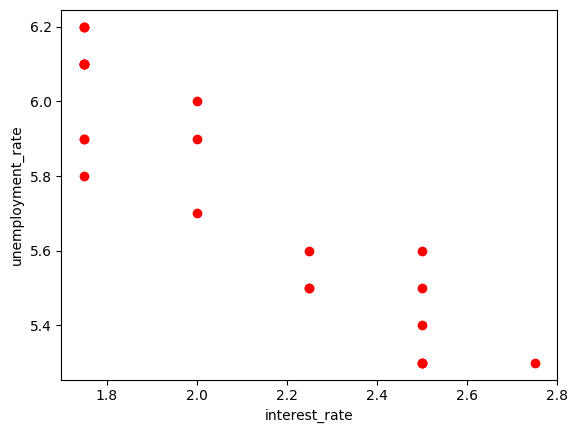

In [12]:
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='red')
plt.xlabel("interest_rate")
plt.ylabel("unemployment_rate")

In [13]:
#independent and dependent features
X=df_index.iloc[:,:-1]
y=df_index.iloc[:,-1]


In [14]:
#train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [15]:
#standardization
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train) # values of X_train is standarized by calculating mean and std deviation
X_test=sc.transform(X_test) # the calculated mean and std deviation are used to standardize the test set so that data leakge problem might not occur

In [16]:
from sklearn.linear_model import LinearRegression # model is learning the relation between input and output features
# it internally calculates the slope and intercept of the line.(y=wx+b)
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [18]:
#cross validation
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(lr,X_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [19]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [20]:
np.average(validation_score)

np.float64(-5914.828180162386)

In [21]:
#prediction
y_pred=lr.predict(X_test)

In [24]:
#performance metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,root_mean_squared_error
print("MSE=",mean_squared_error(y_test,y_pred))
print("MAE=",mean_absolute_error(y_test,y_pred))
print("RMSE=",root_mean_squared_error(y_test,y_pred))
print("R2 score=",r2_score(y_test,y_pred))
print("Adjusted R2=",1-(1-r2_score(y_test,y_pred))*((X_test.shape[0])-(1))/(X_test.shape[0]-X_test.shape[1]-1))


MSE= 5793.762887712569
MAE= 59.935781523235484
RMSE= 76.11677139574805
R2 score= 0.8278978091457145
Adjusted R2= 0.7131630152428576


Assumptions

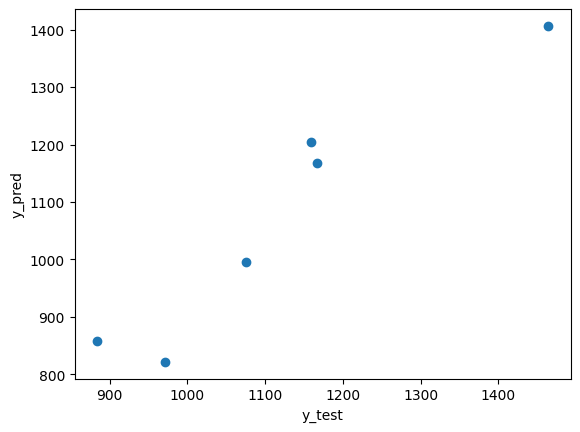

In [25]:
plt.scatter(y_test,y_pred) #will be following linear relationship-i.e model has perfomed well
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.show()

In [27]:
#residuals
residuals=y_test-y_pred
print(residuals)


8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


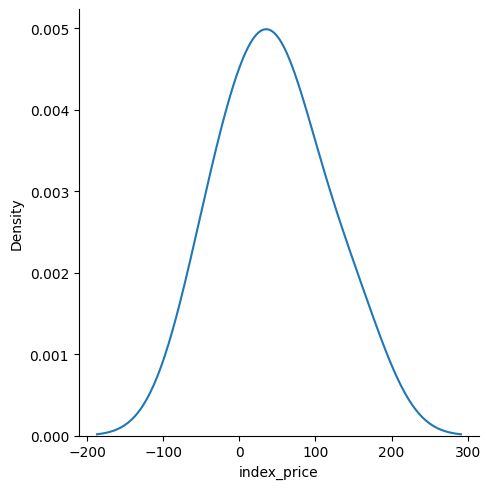

In [28]:
#plot the residuals
sns.displot(residuals,kind='kde')#kernel density estimator--normal distribution means the model we have created is good


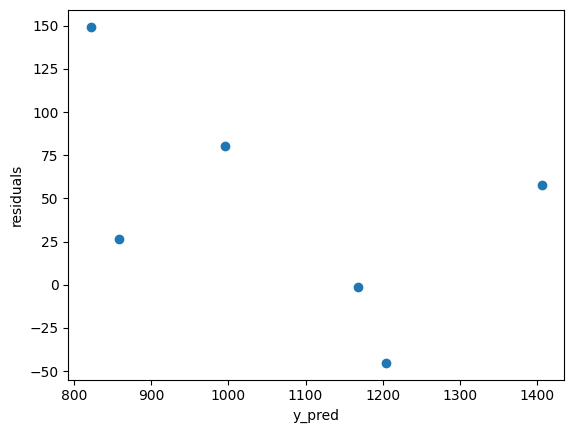

In [29]:
#scatter plot w.r.t predictions and residuals--if this follows uniform method  that means the model is good
plt.scatter(y_pred,residuals)
plt.xlabel("y_pred")
plt.ylabel("residuals")
plt.show()